In [3]:
import numpy as np
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sksurv.metrics import integrated_brier_score, brier_score
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

In [5]:
df_improvement = pd.read_csv("dataset/df_clean.csv")

# Although XGBoost doesn't need scaled inputs, put it anyways to ensure fairness for comparison between baseline and improved model
df_improvement["Minuteso f Use"] = df_improvement["Seconds of Use"] / 60
df_improvement["Charge Amount/10"] = df_improvement["Charge Amount"] / 10
df_improvement = df_improvement.drop(columns=["Seconds of Use", "Charge Amount"])

print(f"Shape: {df_improvement.shape}")

# Train/val/test split is 70/15/15 to not deprive the model from data shortage for training
df_study, df_test = train_test_split(df_improvement, test_size=0.15, stratify=df_improvement['Status'], random_state=42)
df_train, df_val = train_test_split(df_study, test_size=0.1764, stratify=df_study['Status'], random_state=42) # 0.1764 is from 15 / 85 (85 from df_study)
print(f"Shape for training set: {df_train.shape}")
print(f"Shape for validation set: {df_val.shape}")
print(f"Shape for test set: {df_test.shape}")

Shape: (2850, 14)
Shape for training set: (1994, 14)
Shape for validation set: (428, 14)
Shape for test set: (428, 14)


In [6]:
# Drop the targets for X to prevent data leakage 
X_train = df_train.drop(columns=["Subscription Length", "Churn"])

# DMatrix just makes the XGB perform faster later during training
dtrain = xgb.DMatrix(X_train)

# We know that no customers churned before the end of their Subscription Length
y_lower_bound = df_train['Subscription Length'].values

# Let's say if the result is positive, the model knows the customer will churn eventually, 
# but in the meantime, assume they churn between month of their subs length and month infinity or forever
y_upper_bound = np.where(df_train['Churn'] == 0, np.inf, df_train['Subscription Length'].values)

dtrain.set_float_info('label_lower_bound', y_lower_bound)
dtrain.set_float_info('label_upper_bound', y_upper_bound)

X_val = df_val.drop(columns=["Subscription Length", "Churn"])
dval = xgb.DMatrix(X_val)

y_lower_val = df_val['Subscription Length'].values
y_upper_val = np.where(df_val['Churn'] == 0, np.inf, df_val['Subscription Length'].values)

dval.set_float_info('label_lower_bound', y_lower_val)
dval.set_float_info('label_upper_bound', y_upper_val)

X_test = df_test.drop(columns=["Subscription Length", "Churn"])
dtest = xgb.DMatrix(X_test)

y_lower_test = df_test['Subscription Length'].values
y_upper_test = np.where(df_test['Churn'] == 0, np.inf, df_test['Subscription Length'].values)

dtest.set_float_info('label_lower_bound', y_lower_test)
dtest.set_float_info('label_upper_bound', y_upper_test)

In [7]:
parameters = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'learning_rate': 0.01,
    'max_depth': 8,
    'min_child_weight': 10
}

# The paramaters are picked from Random Search, Random Search is used because it's more computationally efficient than Grid Search
# And it experiments a broader range of values of each hyperparameter 
# rather than keep on testing the same significant parameter with different values of insignificant ones (Grid Search does that)

evals = [(dtrain, 'train'), (dval, 'val')]

xgb_model = xgb.train(
    params=parameters, 
    dtrain=dtrain, 
    num_boost_round=500, 
    evals=evals, 
    early_stopping_rounds=20,
    verbose_eval=10  
)

[0]	train-aft-nloglik:11.04934	val-aft-nloglik:11.03947
[10]	train-aft-nloglik:9.32049	val-aft-nloglik:9.30851
[20]	train-aft-nloglik:7.89439	val-aft-nloglik:7.88025
[30]	train-aft-nloglik:6.71669	val-aft-nloglik:6.70075
[40]	train-aft-nloglik:5.74275	val-aft-nloglik:5.72535
[50]	train-aft-nloglik:4.93599	val-aft-nloglik:4.91742
[60]	train-aft-nloglik:4.26662	val-aft-nloglik:4.24732
[70]	train-aft-nloglik:3.71026	val-aft-nloglik:3.69035
[80]	train-aft-nloglik:3.24709	val-aft-nloglik:3.22657
[90]	train-aft-nloglik:2.86080	val-aft-nloglik:2.83991
[100]	train-aft-nloglik:2.53785	val-aft-nloglik:2.51678
[110]	train-aft-nloglik:2.26738	val-aft-nloglik:2.24552
[120]	train-aft-nloglik:2.04041	val-aft-nloglik:2.01811
[130]	train-aft-nloglik:1.84950	val-aft-nloglik:1.82689
[140]	train-aft-nloglik:1.68811	val-aft-nloglik:1.66556
[150]	train-aft-nloglik:1.55133	val-aft-nloglik:1.52864
[160]	train-aft-nloglik:1.43530	val-aft-nloglik:1.41282
[170]	train-aft-nloglik:1.33689	val-aft-nloglik:1.31482
[

In [8]:
pred_times = xgb_model.predict(dtrain)

c_index_train = concordance_index(
    event_times = df_train["Subscription Length"],
    predicted_scores = pred_times,  
    event_observed = df_train["Churn"]
)

pred_times = xgb_model.predict(dtest)

c_index_test = concordance_index(
    event_times = df_test["Subscription Length"],
    predicted_scores = pred_times,  
    event_observed = df_test["Churn"]
)

print(f"XGBoost AFT (Optimized) C-Index in Training: {c_index_train:.4f}")
print(f"XGBoost AFT (Optimized) C-Index in Testing: {c_index_test:.4f}")

XGBoost AFT (Optimized) C-Index in Training: 0.9568
XGBoost AFT (Optimized) C-Index in Testing: 0.9405


<Figure size 1000x600 with 0 Axes>

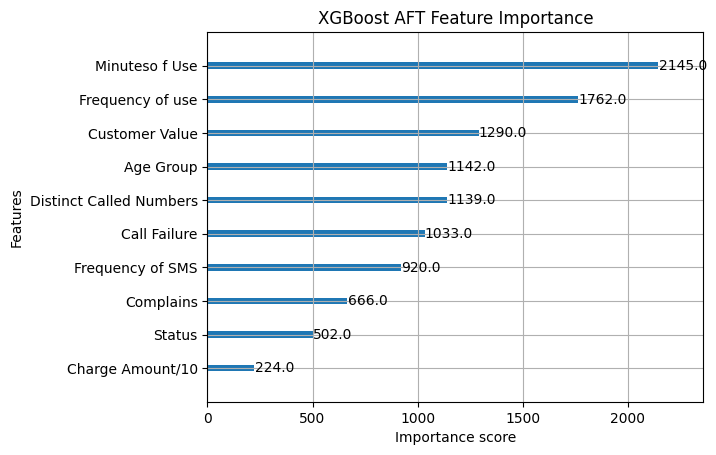

In [9]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    xgb_model, 
    max_num_features=10, 
    importance_type='weight',
    title='XGBoost AFT Feature Importance'
)
plt.show()

In [11]:
# To calculate IBS score, it requires a survival function
# Because XGBoost doesn't output one, but rather a single scalar value that represents the predicted time to churn
# Therefore, y_train, y_test, surv_probs, and time need to be found

y_train = np.array(
    list(zip(df_train['Churn'].astype(bool), df_train['Subscription Length'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)
y_test = np.array(
    list(zip(df_test['Churn'].astype(bool), df_test['Subscription Length'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)
# ? means bool, <f8 means 64-bit float

# min_time is defined bcs the first few months mostly all the customer haven't churned yet and ibs don't know what to do with it
min_time = df_test['Subscription Length'].min()
safe_min_t = int(np.ceil(min_time)) # ceil to ensure it's not outside the lower bound
# The 90th percentile is used to avoid the Kaplan-Meier math cliff (used before reaching the chaotic and noisy end of the dataset)
safe_max_t = np.percentile(df_test['Subscription Length'], 90)
safe_max_t = int(safe_max_t)
times = np.arange(safe_min_t, safe_max_t)

surv_prob = np.zeros((len(pred_times), len(times)))
for i, pred_time in enumerate(pred_times):
    surv_prob[i, :] = norm.sf(times, loc=pred_time, scale=1.5) # row is pred_time of customer, 
    # col is times (timeline for customer)
    # 1.5 is the most realistic scale for customer churn data

ibs = integrated_brier_score(y_train, y_test, surv_prob, times)
print(f"Integrated Brier Score (IBS): {ibs:.4f}")

Integrated Brier Score (IBS): 0.0397


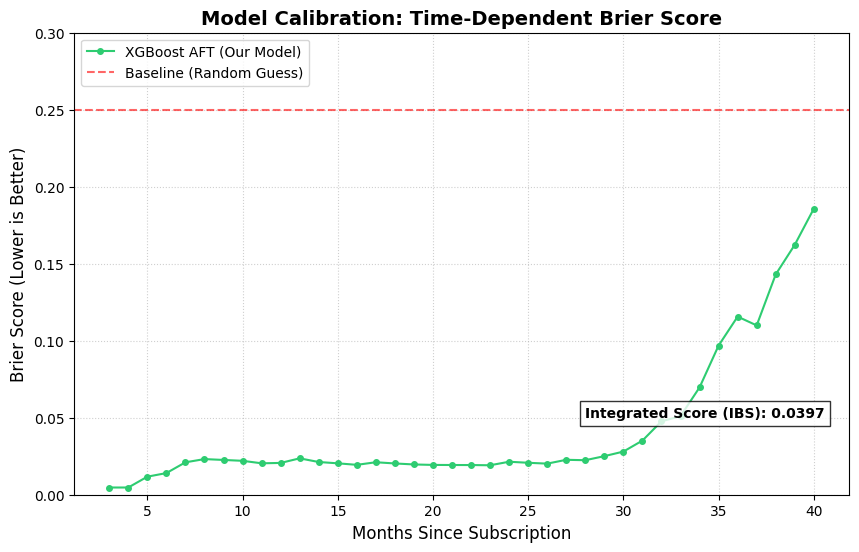

In [12]:
# calculate the raw brier scores for each point in the times grid
time_grid, brier_scores_array = brier_score(y_train, y_test, surv_prob, times)

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(time_grid, brier_scores_array, color='#2ecc71', marker='o', markersize=4, label='XGBoost AFT (Our Model)')
plt.axhline(y=0.25, color='red', linestyle='--', alpha=0.6, label='Baseline (Random Guess)')

plt.title('Model Calibration: Time-Dependent Brier Score', fontsize=14, fontweight='bold')
plt.xlabel('Months Since Subscription', fontsize=12)
plt.ylabel('Brier Score (Lower is Better)', fontsize=12)
plt.ylim(0, 0.3) # 0.3 to show how far the guesses are from the 0.25 (random guess) line
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.text(time_grid.max()*0.7, 0.05, f'Integrated Score (IBS): {ibs:.4f}', 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, fontweight='bold')

plt.show()